## Web scraping


In [3]:
#importing nesessary libraries
import requests
import re
import pandas as pd
from bs4 import BeautifulSoup

# Initialize extracted features
project_names = []
prices = []
sizes = []
locations = []
configurations = []
property_types = []
possession_statuses = []
amenities = []

# Base URL
base_url = "https://www.squareyards.com/sale/apartments-for-sale-in-hyderabad?page="

# Loop through multiple pages to collect data
for page_number in range(1, 15): 
    url = base_url + str(page_number)
    page = requests.get(url)
    soup = BeautifulSoup(page.text, "html.parser")
    
    listings = soup.find_all("div", class_="tlBdy") 

    if not listings:  # Stop if no more listings are found
        break

    # Loop through each listing and extract data
    for listing in listings:
        html_content = listing.get_text(strip=True)

        # Project Name extraction
        project_name_match = re.search(r"Whatsapp(.*?)\d", html_content)
        project_name = project_name_match.group(1).strip() if project_name_match else None
        project_names.append(project_name)

        # Price extraction
        price_match = re.search(r"₹\s*([\d,]+(?:\.\d{1,2})?)\s*(L|Cr)?", html_content)
        price = price_match.group(0).strip() if price_match else None
        prices.append(price)

        # Square Feet extraction
        sqft_match = re.search(r"(\d{3,4})\s*Sq\.Ft\.", html_content)
        sqft = sqft_match.group(1) if sqft_match else None
        sizes.append(sqft)

        # Location extraction
        location_match = re.search(r"Sale in ([\w\s]+)", html_content)
        location = location_match.group(1).strip() if location_match else None
        locations.append(location)

        # Flat Type extraction
        flat_type_match = re.search(r"(\d+)\s*BHK", html_content)
        flat_type = flat_type_match.group(0).strip() if flat_type_match else None
        configurations.append(flat_type)

        # Property Type extraction
        property_type_match = re.search(r"\b(Apartment|Villa|Independent House|Studio)\b", html_content, re.IGNORECASE)
        property_type = property_type_match.group(1).strip() if property_type_match else None
        property_types.append(property_type)

        # Possession Status extraction
        possession_status_match = re.search(r"(Ready To Move|Under Construction)", html_content)
        possession_status = possession_status_match.group(0).strip() if possession_status_match else None
        possession_statuses.append(possession_status)

        # Amenities extraction
        amenities_match = re.findall(r"(Gated Society|Safe & Secure Locality|Affordable|Family|Prime Location)", html_content)
        amenities_list = ", ".join(amenities_match) if amenities_match else None
        amenities.append(amenities_list)

# Create the DataFrame
data1 = {
    "Project Name": project_names,
    "Location": locations,
    "Square Feet": sizes,
    "Flat Type": configurations,
    "Property Type": property_types,
    "Price": prices,
    "Possession Status": possession_statuses,
    "Amenities": amenities,
}


In [5]:
df = pd.DataFrame(data1)

## Converting data to csv file

In [8]:
#improrting libaries
import pandas as pd
import numpy as np

In [10]:
df.to_csv(r"C:\Users\kotho\OneDrive\Documents\apartments_data.csv", index=False)
#converting collected data into csv file

In [12]:
#fisrt 5 rows from data
df.head()

,Project Name,Location,Square Feet,Flat Type,Property Type,Price,Possession Status,Amenities
0,Unison Padmavathi Flora,Padmarao Nagar,680,2 BHK,None,₹ 18 L,None,None
1,Prestige High Fields,Gachibowli,1492,5 BHK,apartment,₹ 1.84 Cr,Ready To Move,"Gated Society, Prime Location, Family"
2,Pragathis Raghupathi County,Bachupally,1265,2 BHK,apartment,₹ 89 L,Ready To Move,"Gated Society, Safe & Secure Locality, Afforda..."
3,Prestige Tranquil,Kokapet,2049,5 BHK,None,₹ 2.1 Cr,Ready To Move,Prime Location
4,EIPL Corner Stone,Gandipet,2065,3 BHK,apartment,₹ 1.9 Cr,Ready To Move,"Gated Society, Affordable, Family"


In [14]:
#copying data to other variable as to perform manupilation on the copy data as no permannent changes on the collected data
data=df.copy()

In [16]:
#checking for info of data to know about the data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Project Name       535 non-null    object
 1   Location           535 non-null    object
 2   Square Feet        533 non-null    object
 3   Flat Type          535 non-null    object
 4   Property Type      295 non-null    object
 5   Price              532 non-null    object
 6   Possession Status  523 non-null    object
 7   Amenities          447 non-null    object
dtypes: object(8)
memory usage: 33.6+ KB


In [18]:
#checking for null values in data
data.isnull().sum()

Project Name           0
Location               0
Square Feet            2
Flat Type              0
Property Type        240
Price                  3
Possession Status     12
Amenities             88
dtype: int64

In [20]:
#checking for dupliacted in data
data.duplicated().sum()

7

## Data cleaning

In [23]:
#filling the missing values 
data["Property Type"].bfill(axis=0,inplace=True)
data["Amenities"].ffill(axis=0,inplace=True)

In [25]:
data["Possession Status"].fillna("Under Construction",inplace=True)

In [27]:
#giving value to the misiing value in bhk
data["Flat Type"][0]="2 BHK"

In [29]:
# changing column name
data.rename(columns={"Flat Type":"BHK"}, inplace=True)

In [31]:
# cleaning BHK data 
data["BHK"]=data['BHK'].str.replace(' BHK', "")

In [33]:
#filling null values in column BHK

data["BHK"].fillna(2,inplace=True)
data["BHK"].astype(int)

0      2
1      5
2      2
3      5
4      3
      ..
530    5
531    2
532    3
533    2
534    3
Name: BHK, Length: 535, dtype: int32

In [35]:
#cleaning BHK column data as removing BHK tsring from data to perform numerical operations
data['BHK'] = data['BHK'].apply(lambda x: int(str(x)[0]) if len(str(x)) > 1 else int(x))

In [37]:
#checking the null values in column squarefeet
data[data["Square Feet"].isna()]

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
339,Hilltons Hillcrest,Janachaitanya Colony,None,4,apartment,₹ 90 L,Ready To Move,Family
411,Mayfair Villas Tellapur,Tellapur,None,4,apartment,₹ 6.6 Cr,Ready To Move,Family


In [39]:
data[data["Location"]=="Janachaitanya Colony"]
# here checking for data related to location of Janachaitanya Colony..

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
339,Hilltons Hillcrest,Janachaitanya Colony,None,4,apartment,₹ 90 L,Ready To Move,Family


In [41]:
data[data["Location"]=="Ameenpur"] 
# here checking for data related to location of Ameenpur

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
72,Urbanrise Spring Is In The Air,Ameenpur,918,2,apartment,₹ 68 L,Ready To Move,"Prime Location, Family"
136,MCOR Vilaasam,Ameenpur,1100,2,apartment,₹ 63.8 L,Ready To Move,"Gated Society, Prime Location"
141,MCOR Vilaasam,Ameenpur,1500,3,apartment,₹ 87 L,Ready To Move,Gated Society
185,Urbanrise Spring Is In The Air,Ameenpur,1039,5,apartment,₹ 57.14 L,Ready To Move,"Prime Location, Family"
189,Sai RR Ankura,Ameenpur,1415,3,apartment,₹ 77.81 L,Ready To Move,Family
257,Sai RR Ankura,Ameenpur,1415,3,apartment,₹ 75 L,Under Construction,"Prime Location, Gated Society, Safe & Secure L..."
287,Urbanrise Spring Is In The Air,Ameenpur,1039,5,apartment,₹ 70 L,Under Construction,"Affordable, Family"
399,Urbanrise Spring Is In The Air,Ameenpur,918,2,apartment,₹ 50.49 L,Under Construction,"Prime Location, Family"
509,Urbanrise Spring Is In The Air,Ameenpur,810,2,apartment,₹ 44.55 L,Ready To Move,Prime Location


In [43]:
data.loc[(data["Location"] == "Ameenpur") & (data["Square Feet"].isna()), "Square Feet"] = "1100"
##calculating and adding the misiing value in location Ameenpur

In [45]:
data[data["Location"]=="Ameenpur"]
#checking wheather value got updated or not

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
72,Urbanrise Spring Is In The Air,Ameenpur,918,2,apartment,₹ 68 L,Ready To Move,"Prime Location, Family"
136,MCOR Vilaasam,Ameenpur,1100,2,apartment,₹ 63.8 L,Ready To Move,"Gated Society, Prime Location"
141,MCOR Vilaasam,Ameenpur,1500,3,apartment,₹ 87 L,Ready To Move,Gated Society
185,Urbanrise Spring Is In The Air,Ameenpur,1039,5,apartment,₹ 57.14 L,Ready To Move,"Prime Location, Family"
189,Sai RR Ankura,Ameenpur,1415,3,apartment,₹ 77.81 L,Ready To Move,Family
257,Sai RR Ankura,Ameenpur,1415,3,apartment,₹ 75 L,Under Construction,"Prime Location, Gated Society, Safe & Secure L..."
287,Urbanrise Spring Is In The Air,Ameenpur,1039,5,apartment,₹ 70 L,Under Construction,"Affordable, Family"
399,Urbanrise Spring Is In The Air,Ameenpur,918,2,apartment,₹ 50.49 L,Under Construction,"Prime Location, Family"
509,Urbanrise Spring Is In The Air,Ameenpur,810,2,apartment,₹ 44.55 L,Ready To Move,Prime Location


In [47]:
#checking null value in price
data[data["Price"].isna()]

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
222,Muppa Melody,Gachibowli,1010,2,apartment,None,Ready To Move,"Affordable, Family"
321,Raghava Capital,Financial District,1099,4,apartment,None,Under Construction,"Affordable, Family"
452,My Home Bhooja,Hi Tech City,2680,5,apartment,None,Ready To Move,"Gated Society, Safe & Secure Locality, Family"


In [49]:
data[(data["Location"] == "Financial District") & (data["BHK"]==4)]
#checking data related to location of Financial District

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
120,SAS Diamond Towers,Financial District,3740,4,apartment,₹ 3.55 Cr,Under Construction,Prime Location
227,Raghava Capital,Financial District,0999,4,apartment,₹ 13.19 Cr,Under Construction,"Affordable, Family"
321,Raghava Capital,Financial District,1099,4,apartment,None,Under Construction,"Affordable, Family"
338,Candeur Skyline,Financial District,6520,4,apartment,₹ 8.15 Cr,Under Construction,"Affordable, Family"


In [51]:
data.loc[(data["Location"] == "Financial District") & (data["Price"].isna()), "Price"] = "14.51 Cr"
#claculated value manually by checking the data in location of Financial District and filled missing value.

In [53]:
data[(data["Location"] == "Financial District")]

,Project Name,Location,Square Feet,BHK,Property Type,Price,Possession Status,Amenities
42,ASBL Spectra,Financial District,2220,3,apartment,₹ 2.2 Cr,Under Construction,"Prime Location, Family"
120,SAS Diamond Towers,Financial District,3740,4,apartment,₹ 3.55 Cr,Under Construction,Prime Location
168,ASBL Loft,Financial District,1870,3,apartment,₹ 1.73 Cr,Under Construction,"Prime Location, Gated Society"
227,Raghava Capital,Financial District,0999,4,apartment,₹ 13.19 Cr,Under Construction,"Affordable, Family"
274,ASBL Loft,Financial District,1695,3,apartment,₹ 1.55 Cr,Under Construction,"Affordable, Family"
321,Raghava Capital,Financial District,1099,4,apartment,14.51 Cr,Under Construction,"Affordable, Family"
338,Candeur Skyline,Financial District,6520,4,apartment,₹ 8.15 Cr,Under Construction,"Affordable, Family"
359,Manbhum Around The Grove,Financial District,4400,3,apartment,₹ 5.15 Cr,Ready To Move,"Safe & Secure Locality, Affordable, Family"
447,SAS Diamond Towers,Financial District,2715,3,apartment,₹ 2.44 Cr,Under Construction,"Affordable, Family"


In [55]:
#dropping null values from data after cleaning
data.dropna(inplace=True)

In [57]:
#checking dupocate values in data
data.duplicated().sum()

10

In [59]:
#droping duplicate values in data
data.drop_duplicates(inplace=True)

In [61]:
#after cleaning and removing duplicate values checking the info of data to know..
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520 entries, 1 to 534
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Project Name       520 non-null    object
 1   Location           520 non-null    object
 2   Square Feet        520 non-null    object
 3   BHK                520 non-null    int64 
 4   Property Type      520 non-null    object
 5   Price              520 non-null    object
 6   Possession Status  520 non-null    object
 7   Amenities          520 non-null    object
dtypes: int64(1), object(7)
memory usage: 36.6+ KB


In [63]:
#changing column dtype to correct data type to perform analysis
data["Square Feet"]=data["Square Feet"].astype(int)

## Data Manipulation

In [66]:
# Function to clean and convert the Price column to lakh
def convert_price(price):
    
    # Remove the rupee symbol and spaces
    price = price.replace("₹", "").strip()
    value, unit = price.split()  # Split into value and unit (e.g., '1.9', 'Cr')
    value = float(value)  # Convert value to float
    if unit.upper() == "CR":
        return value * 100  # Convert crore to lakh
    return value  # Lakhs remain unchanged

# Apply conversion to the Price column
data["Price"] = data["Price"].apply(convert_price)


In [68]:
data["Price"]=data["Price"].astype(float)

In [70]:
#Adding new column price_per_sqft
data["Price_per_sqft"]= (data['Price'] / data['Square Feet'])*100000
data["Price_per_sqft"] = data["Price_per_sqft"].round(2)

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 520 entries, 1 to 534
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Project Name       520 non-null    object 
 1   Location           520 non-null    object 
 2   Square Feet        520 non-null    int32  
 3   BHK                520 non-null    int64  
 4   Property Type      520 non-null    object 
 5   Price              520 non-null    float64
 6   Possession Status  520 non-null    object 
 7   Amenities          520 non-null    object 
 8   Price_per_sqft     520 non-null    float64
dtypes: float64(2), int32(1), int64(1), object(5)
memory usage: 38.6+ KB


In [74]:
#describe provides an overview of the central tendency (mean, median) and spread (standard deviation, range) of numerical data.
data.describe()

,Square Feet,BHK,Price,Price_per_sqft
count,520.000000,520.000000,520.000000,520.000000
mean,1992.873077,3.065385,195.720019,9265.024962
std,1133.078887,1.164485,184.675187,8274.333133
min,787.000000,1.000000,18.670000,1208.690000
25%,1329.000000,2.000000,92.625000,6611.092500
50%,1653.500000,3.000000,136.000000,8468.575000
75%,2186.250000,3.000000,218.500000,10496.467500
max,9299.000000,9.000000,1451.000000,132032.030000


## Univariate Analysis

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\kotho\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


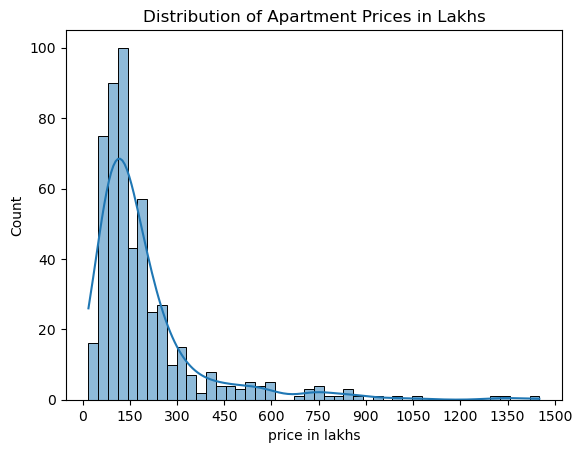

In [78]:
sns.histplot(data['Price'], kde=True)
plt.xlabel("price in lakhs")
plt.title("Distribution of Apartment Prices in Lakhs")
plt.xticks(ticks=range(0, int(data['Price'].max()) + 150, 150))
plt.show()
#The histogram shows a right-skewed distribution
#where the majority of prices are clustered towards the lower range, and only a few apartments have high prices.
#A tail is visible on the right, indicating that a small number of high-priced apartments are present.
#The smooth curve shows the probability density

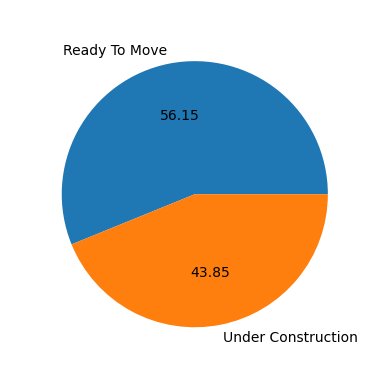

In [81]:
plt.pie(x=data["Possession Status"].value_counts().values,labels=data["Possession Status"].value_counts().index,autopct="%0.2f",radius=0.9)
plt.show()
#A majority (55.81%) of properties of "Ready to Move," indicating that more than half of the properties are already completed and available for immediate possession.
#A  proportion of properties (44.19%) are still "Under Construction," showing that a large share of the market is in the development phase.

C:\Users\kotho\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


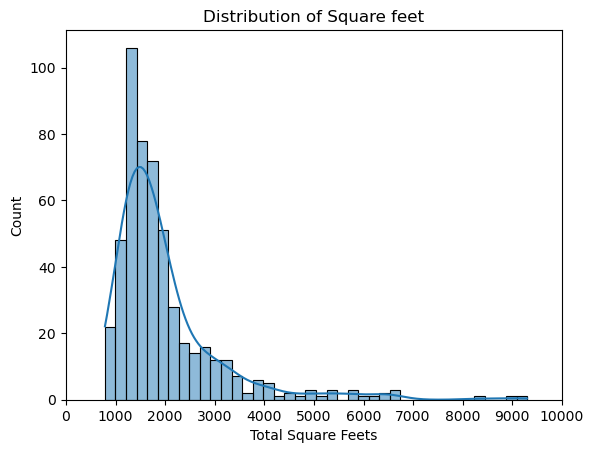

In [83]:
sns.histplot(data["Square Feet"],kde=True)
plt.xlabel("Total Square Feets")
plt.title("Distribution of Square feet")
plt.xticks(ticks=range(0, int(data['Square Feet'].max()) + 1000, 1000))
plt.show()
#The majority of properties have a total square feet in  between 1000 and 2000 square feet, as indicated by the highest bars in this range.
#The distribution is right-skewed, meaning there are a smaller number of properties with very large square feets

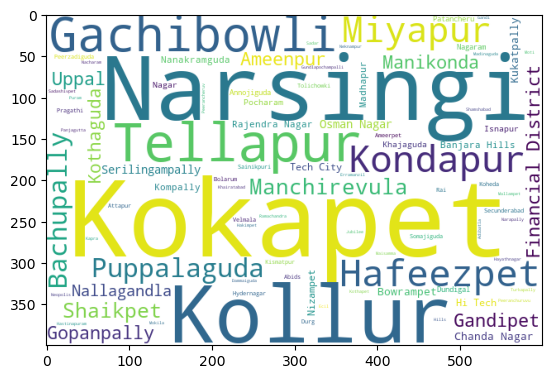

In [85]:
import wordcloud
from wordcloud import WordCloud
img1=WordCloud(width=600,height=400,background_color='white').generate(" ".join(data["Location"]))
plt.imshow(img1)
#frequency of locations 
#This visualization is helpful in identifying high-listed values of apartments.
#Locations like Kokapet, Narsingi, Kollur, and Tellapur appear more frequently in your dataset as they are shown in larger font sizes.
#Locations such as Gachibowli, Bachupally, and Manchirevula are displayed in medium-sized fonts, indicating a moderate frequency of occurrence.
#Smaller text indicates locations that appear less frequently in your data, such as Hafeezpet, Ameenpur, and Miyapur.

## Bivariate analysis

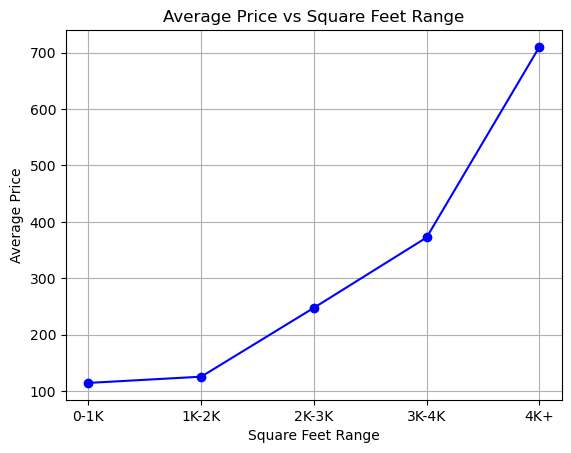

In [88]:
data['Square Feet Range'] = '0' # Default value
data.loc[data['Square Feet'] <= 1000, 'Square Feet Range'] = '0-1K'
data.loc[(data['Square Feet'] > 1000) & (data['Square Feet'] <= 2000), 'Square Feet Range'] = '1K-2K'
data.loc[(data['Square Feet'] > 2000) & (data['Square Feet'] <= 3000), 'Square Feet Range'] = '2K-3K'
data.loc[(data['Square Feet'] > 3000) & (data['Square Feet'] <= 4000), 'Square Feet Range'] = '3K-4K'
data.loc[data['Square Feet'] > 4000, 'Square Feet Range'] = '4K+'

# Calculate the average price for each square feet range
grouped_data = data.groupby("Square Feet Range")["Price"].mean().reset_index()

# Plot the data
plt.plot(grouped_data["Square Feet Range"], grouped_data["Price"], marker="o", color="b")
plt.title("Average Price vs Square Feet Range")
plt.xlabel("Square Feet Range")
plt.ylabel("Average Price")
plt.grid(True)
plt.show()

#It indicates that larger properties (with more square feet) tend to have higher prices.
# As the square feet increases gradually the priceses are also increasing.

Text(0.5, 1.0, 'BHK vs Price')

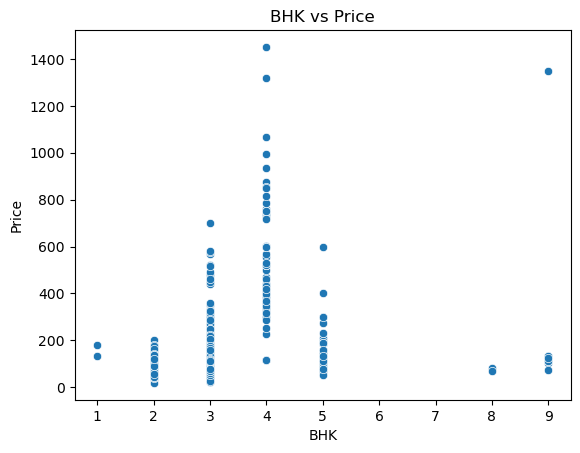

In [90]:
sns.scatterplot(x=data['BHK'], y=data['Price']) 
plt.title("BHK vs Price")
#Properties with 4 bedrooms have the highest average price compared to other categories.

Text(0.5, 1.0, 'Scatter Plot of BHK vs. Square Feet')

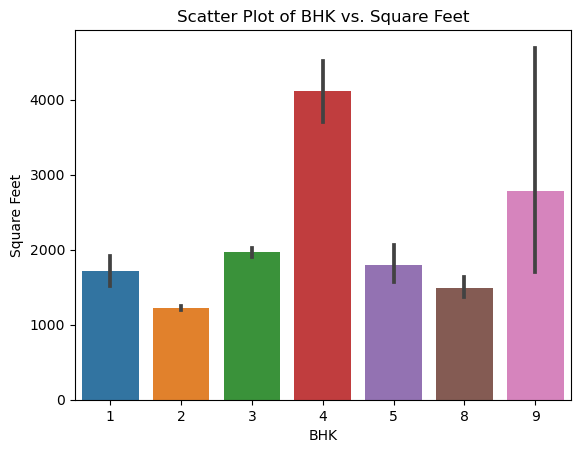

In [92]:
sns.barplot(x=data['BHK'], y=data['Square Feet'])
plt.title("Scatter Plot of BHK vs. Square Feet")
#Generally, as the number of bedrooms (BHK) increases, the range of square feet also tends to increase.
#For example, properties with 4 BHK often have larger square feet than those with 1 or 2 BHK.
#There is a large spread of square feet values for 4 BHK properties, ranging from around 2000 sq. ft. to above 8000 sq. ft.
#The 1 and 2 BHK properties mostly have square feet below 2000, indicating that these are likely to individuals or small families.
#For 7 BHK and above, there are fewer data points  are moderate as possibly less popular market segments.

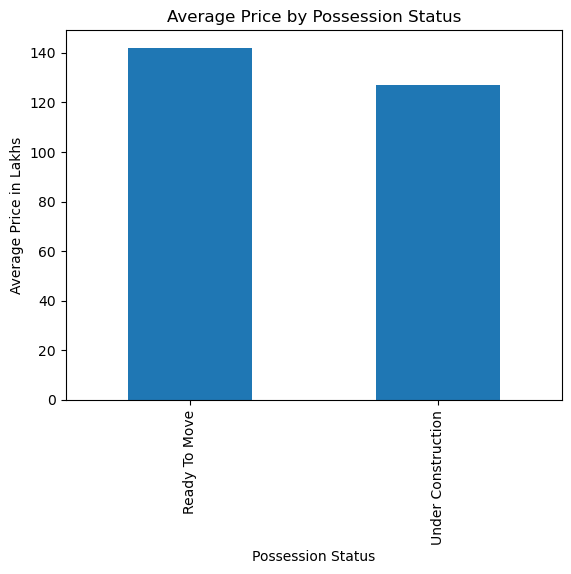

In [94]:
data.groupby('Possession Status')['Price'].median().plot(kind='bar')
plt.title('Average Price by Possession Status')
plt.xlabel('Possession Status')
plt.ylabel('Average Price in Lakhs')
plt.show()
#The average prices for both "Ready to Move" and "Under Construction" properties are very close.
#"Under Construction" properties having a slightly higher average price.

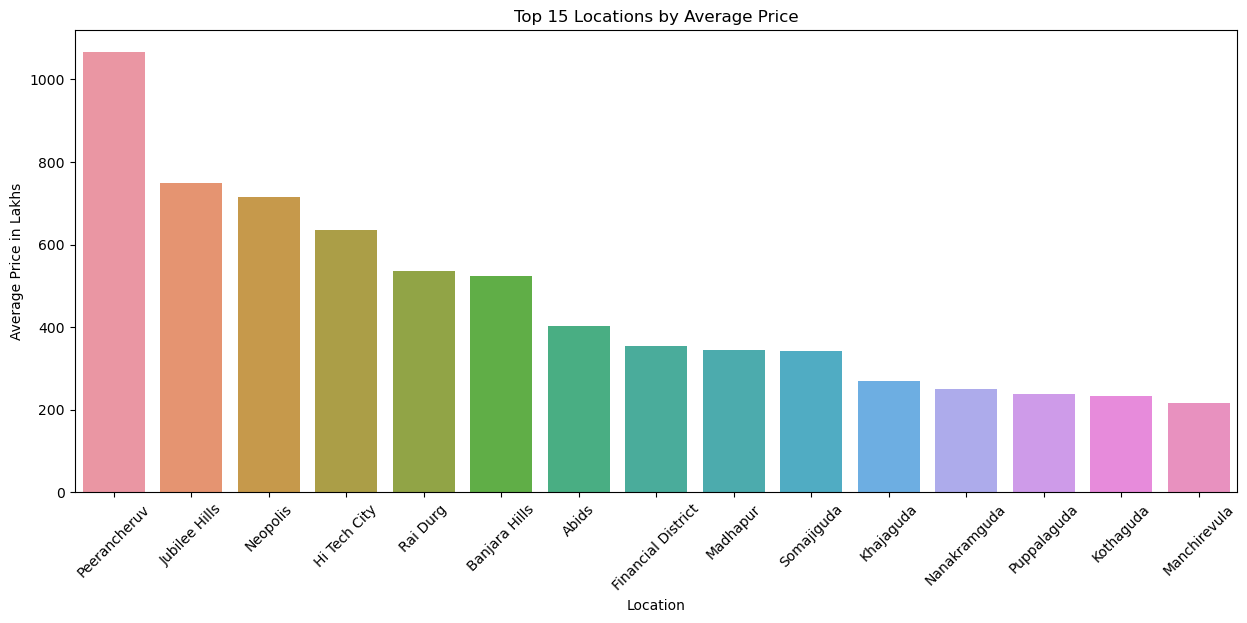

In [96]:
average_price_by_location = data.groupby("Location")["Price"].median().reset_index()

# Sort the values by price in descending order
average_price_by_location = average_price_by_location.sort_values("Price", ascending=False)

# Select the top 15 locations by average price
top_15_locations = average_price_by_location.head(15)

# Plotting the bar chart for top 15 locations
plt.figure(figsize=(15, 6))
sns.barplot(x="Location", y="Price", data=top_15_locations)
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.title("Top 15 Locations by Average Price")
plt.xlabel("Location")
plt.ylabel("Average Price in Lakhs")
plt.show()

## Multivariate analysis

C:\Users\kotho\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kotho\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kotho\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


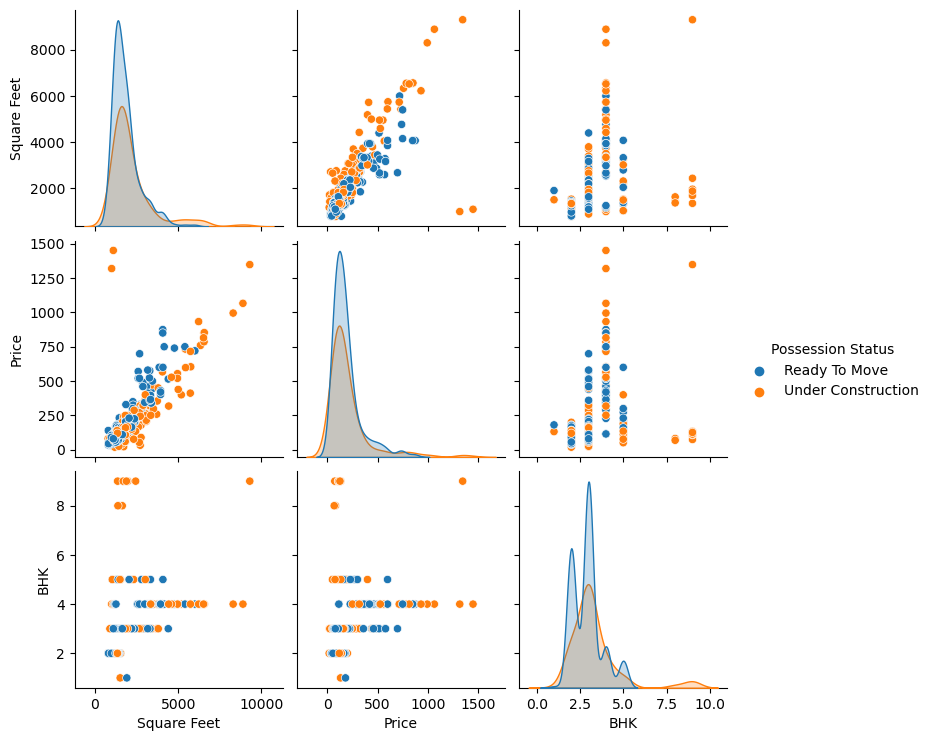

In [98]:
sns.pairplot(data, vars=['Square Feet', 'Price', 'BHK'], hue='Possession Status')
plt.show()
#The diagonal plots show the distribution of each variable. Most properties fall in the range of 0-5000 square feet, 0-1000 in price, and 2-3 BHKs.
#The plot differentiates between properties that are "Ready To Move" and "Under Construction


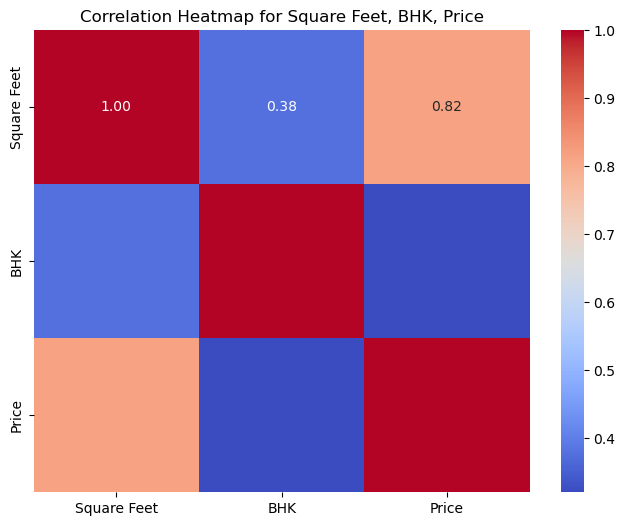

In [100]:
# Correlation heatmap for numeric features
corr_matrix = data[["Square Feet", "BHK", "Price"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title('Correlation Heatmap for Square Feet, BHK, Price')
plt.show()

#1.00: A perfect positive correlation. This means that as one variable increases, the other variable also increases proportionally.
#0.35: A moderate positive correlation.
#This means that there is a positive relationship between the two variables, but it's not as strong as a perfect correlation.
#0.81: A strong positive correlation. This means that there is a strong positive relationship between the two variables.

In [102]:
#Suggesting the list of properties based on the criteria of BHK and price ranges and preferred location of buyers?

In [112]:
def get_user_input():
    location = input("Enter your preferred location: ").strip()
    bhk = int(input("Enter your preferred BHK: ").strip())
    min_price = float(input("Enter your minimum price range: ").strip())
    max_price = float(input("Enter your maximum price range: ").strip())
    possession_state = input("Enter your preferred possession state (e.g., 'Ready to Move' or 'Under Construction'): ").strip()
    return location, bhk, min_price, max_price, possession_state

def recommend_properties(data, location, bhk, min_price, max_price, possession_state):
    # Standardize the location input and possession state for case-insensitive matching
    location = location.title()
    possession_state = possession_state.title()

    # Filter the dataset
    filtered_df = data[
        (data['Location'].str.title() == location) & 
        (data['BHK'] == bhk) & 
        (data['Price'] >= min_price) & 
        (data['Price'] <= max_price) & 
        (data['Possession Status'].str.title() == possession_state)
    ]

    # Display results
    if filtered_df.empty:
        print("No properties found matching your criteria.")
    else:
        print("Recommended Properties:")
        print(filtered_df[['Project Name', 'Location', 'Square Feet', 'BHK', 'Price', 'Possession Status']])

# Main Execution: Get user input and recommend properties
location, bhk, min_price, max_price, possession_state = get_user_input()
recommend_properties(data, location, bhk, min_price, max_price, possession_state)


Enter your preferred location:  gachibowli
Enter your preferred BHK:  2
Enter your minimum price range:  60
Enter your maximum price range:  90
Enter your preferred possession state (e.g., 'Ready to Move' or 'Under Construction'):  Ready to Move


Recommended Properties:
        Project Name    Location  Square Feet  BHK  Price Possession Status
514  Mantri Celestia  Gachibowli          980    2   90.0     Ready To Move
